# Description of the first homework assignment  

Consider a picture representing a white sheet of A4 paper with some handwritten numbers in a dark color (they have different sizes, but they are all oriented in the same direction, which is aligned with one of the edges of the paper).  Consider the attached pictures as examples. Some are easy, others are harder. Note that the paper might be pictured at an angle or from a slanted perspective.  In all pictures the four edges of the paper are clearly visible, but might be incomplete.

Write a notebook that, given a directory, will process all images in that directory and extract all digits it can find from each picture. For each file, it should then print:
- the name of the file, followed by  
- each of the digits that has been identified on that sheet of paper, from top to bottom.

### Examples
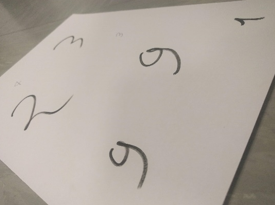 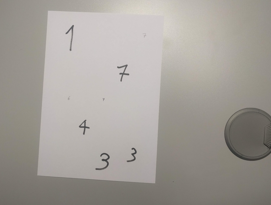 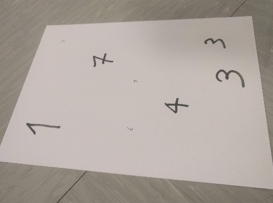 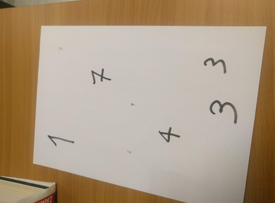

## Imports

In [1]:
import skimage
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pathlib
import ipywidgets as widgets
import math
import random
import itertools

from typing import Self

## Helper classes
- ImageItem
- ImageCollection
- LineItem

In [2]:
class ImageItem:
    def __init__(self, path: pathlib.Path):
        self.path = path
    
    def load(self):
        return self.__load(self.path)
    
    def load_grayscale(self):
        return skimage.color.rgb2gray(self.__load(self.path))        
    
    @staticmethod
    def __load(path: pathlib.Path):
        return skimage.io.imread(path)


class ImageCollection:
    def __init__(self, dir_path: pathlib.Path | str | None = None):
        self.__entries: list[ImageItem] = self.__scan_dir(dir_path) if dir_path else []
    
    def __len__(self) -> int:
        return len(self.__entries)

    def __getitem__(self, key: slice | str | int) -> Self | pathlib.Path:
        if isinstance(key, slice):
            return ImageCollection().__add_entries(self.__entries[key])
        
        if isinstance(key, str):
            return self.__get_item_by_name(key)
        
        if isinstance(key, int):
            return self.__entries[key]
        
        raise TypeError(f'Type {type(key)} not supported!')

    def __add_entries(self, entries: list):
        self.__entries.extend(entries)
        
        return self

    def __scan_dir(self, dir_path: pathlib.Path | str):
        return [ImageItem(path) for path in pathlib.Path(dir_path).rglob('*') if path.suffix == '.jpg']
    
    def __get_item_by_name(self, name: str) -> ImageItem | None:
        item: ImageItem
        for item in self.__entries:
            if item.path.name == name:
                return item
        
        return None


class LineItem:
    def __init__(self, p0, p1):
        self.p0: np.array = np.array([*p0, 1.0], dtype=float)
        self.p1: np.array = np.array([*p1, 1.0], dtype=float)
        self.length: np.float64 = self.__calc_euclidean_distance(self.p0, self.p1)
        self.slope: float = self.__calc_slope(self.p0, self.p1)
        self.slope_rad: float = math.atan(self.slope)
        self.intercept: np.array[float] = self.__calc_intercept(self.p1, self.slope)
        self.h_coords: np.array[float] = np.cross(self.p0, self.p1)
        self.midpoint: np.array = (self.p0 + self.p1) / 2

    def __str__(self):
        return f'P0: {self.p0}, P1: {self.p1}, H-Coords: {self.h_coords} , Length: {self.length:.3f}, Slope: {self.slope:.3f}, Slope (Rad): {self.slope_rad:.3f}, X-Intercept: {self.intercept[0]:.3f}, Y-Intercept: {self.intercept[1]:.3f}'

    @staticmethod
    def __calc_intercept(point: tuple[int], slope: float) -> float:
        x = math.inf if slope == 0.0 else point[0] - point[1] / slope
        y = slope if slope == math.inf else point[1] - slope * point[0]

        return np.array([x, y])

    @staticmethod
    def __calc_euclidean_distance(p0: np.array, p1: np.array):
        return np.linalg.norm(p0[:-1] - p1[:-1])

    @staticmethod
    def __calc_slope(point_0: np.array, point_1: np.array) -> float:     
        if point_1[0] == point_0[0]:  # if parallel to y
            return math.inf

        return (point_1[1] - point_0[1]) / (point_1[0] - point_0[0])

## Functions

In [ ]:
def adjust_contrast(image, lower_threshold_pct: int, higher_threshold_pct: int):
    """Performs contrast stretching on an image using specified percentile thresholds.
  
    Args:
        image (ndarray): Input image as a NumPy array (grayscale or RGB).
        lower_threshold_pct (int): Lower percentile (e.g., 1) to define minimum intensity.
        higher_threshold_pct (int): Upper percentile (e.g., 80) to define maximum intensity.

    Returns:
        ndarray: Image with contrast adjusted by rescaling intensities between the specified percentiles.
    """
    lower_p, higher_p = np.percentile(image, (1, 80))
    img_adjusted = skimage.exposure.rescale_intensity(image, in_range=(lower_p, higher_p))
    
    return img_adjusted

def canny_filtering()

## FilterChain

In [3]:
images = ImageCollection(pathlib.Path.cwd())

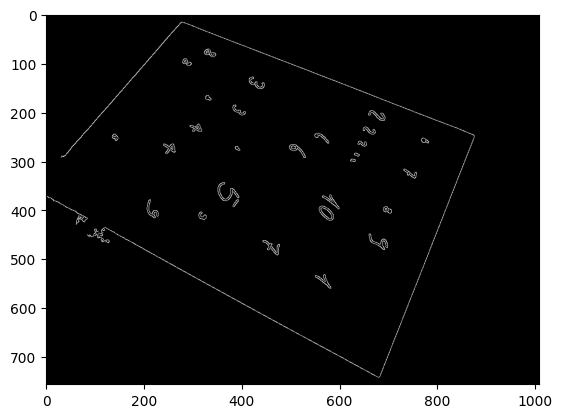

In [ ]:
img = images['IMG_20190325_190103.jpg'].load_grayscale()
img_greysacle = skimage.transform.rescale(img, 0.250)
img_adjusted_contrast = adjust_contrast(img_greysacle, lower_threshold_pct=1, higher_threshold_pct=80)
img_edges = skimage.feature.canny(img_adjusted_contrast, low_threshold=0.1, high_threshold=0.7, sigma=1.5)



plt.imshow(img_edges, cmap='gray')
